# 01 — Exploratory Data Analysis
**Project:** Heart Disease Classification (MLOps Assignment — AIMLCZG523)  
**Dataset:** UCI Heart Disease — Cleveland + Hungarian + Switzerland + VA (~900 rows, 13 features)  
**Target:** `target` — 0 = No Disease, 1 = Disease Present

---
### Notebook Structure
1. Setup & Data Loading  
2. Dataset Overview  
3. Class Balance  
4. Feature Histograms  
5. Continuous Feature Deep-Dive (box plots by class)  
6. Correlation Heatmap  
7. Pairplot — Key Continuous Features  
8. Categorical Feature Breakdown (count plots by class)  
9. Key Findings Summary


## 1 · Setup & Data Loading

In [9]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# ── Style ──────────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams.update({"figure.dpi": 120, "figure.facecolor": "white"})
PALETTE = {0: "#4C72B0", 1: "#DD8452"}   # blue = no disease, orange = disease

# ── Robust project root resolution ─────────────────────────────────────────
# Works whether Jupyter is launched from project root, notebooks/, or anywhere else.
def _find_project_root(marker: str = "data") -> Path:
    """Walk up from this notebook until we find the project root (contains /data/)."""
    # __file__ is not defined in notebooks; use cwd as anchor instead
    candidate = Path.cwd()
    for _ in range(6):  # max 6 levels up
        if (candidate / marker).is_dir():
            return candidate
        candidate = candidate.parent
    raise FileNotFoundError(
        f"Could not find project root (looked for a '{marker}/' folder up to 6 levels). "
        f"Make sure 'data/raw/heart_disease.csv' exists and you are running this notebook "
        f"from inside the mlops-heart-disease project directory."
    )

PROJECT_ROOT = _find_project_root()
RAW_CSV = PROJECT_ROOT / "data" / "raw" / "heart_disease_raw.csv"

print(f"Project root : {PROJECT_ROOT}")
print(f"Data file    : {RAW_CSV}")
print(f"Exists       : {RAW_CSV.exists()}")

if not RAW_CSV.exists():
    print("\n⚠️  Data file not found.")
    print("   Run this from the project root first:")
    print("   python -m src.data.download_data")


Project root : /Users/aadhirachhibber/Desktop/MLOPs_Assignment1/mlops-heart-disease
Data file    : /Users/aadhirachhibber/Desktop/MLOPs_Assignment1/mlops-heart-disease/data/raw/heart_disease_raw.csv
Exists       : True


In [10]:
df = pd.read_csv(RAW_CSV)

# Canonical column names (matches preprocess.py)
COLUMN_NAMES = [
    "age", "sex", "cp", "trestbps", "chol",
    "fbs", "restecg", "thalach", "exang",
    "oldpeak", "slope", "ca", "thal", "target"
]
if df.columns.tolist() != COLUMN_NAMES:
    if len(df.columns) == 14:
        df.columns = COLUMN_NAMES
    else:
        raise ValueError(f"Unexpected column count: {len(df.columns)}")

# Binarise target if not already done
df["target"] = (df["target"] > 0).astype(int)

print(f"Shape: {df.shape}")
df.head()


Shape: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


## 2 · Dataset Overview

In [11]:
print("=== dtypes & non-null counts ===")
df.info()


=== dtypes & non-null counts ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(3), int64(11)
memory usage: 33.3 KB


In [12]:
print("=== Descriptive statistics — continuous features ===")
CONTINUOUS = ["age", "trestbps", "chol", "thalach", "oldpeak"]
df[CONTINUOUS].describe().round(2)


=== Descriptive statistics — continuous features ===


,age,trestbps,chol,thalach,oldpeak
count,303.00,303.00,303.00,303.00,303.00
mean,54.44,131.69,246.69,149.61,1.04
std,9.04,17.60,51.78,22.88,1.16
min,29.00,94.00,126.00,71.00,0.00
25%,48.00,120.00,211.00,133.50,0.00
50%,56.00,130.00,241.00,153.00,0.80
75%,61.00,140.00,275.00,166.00,1.60
max,77.00,200.00,564.00,202.00,6.20


In [13]:
print("=== Missing values ===")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({"count": missing, "pct": missing_pct}).query("count > 0")


=== Missing values ===


,count,pct
ca,4,1.32
thal,2,0.66


## 3 · Class Balance
Target distribution: `0` = No Disease, `1` = Disease Present.  
A severe imbalance would require SMOTE or class-weighting — we check here.


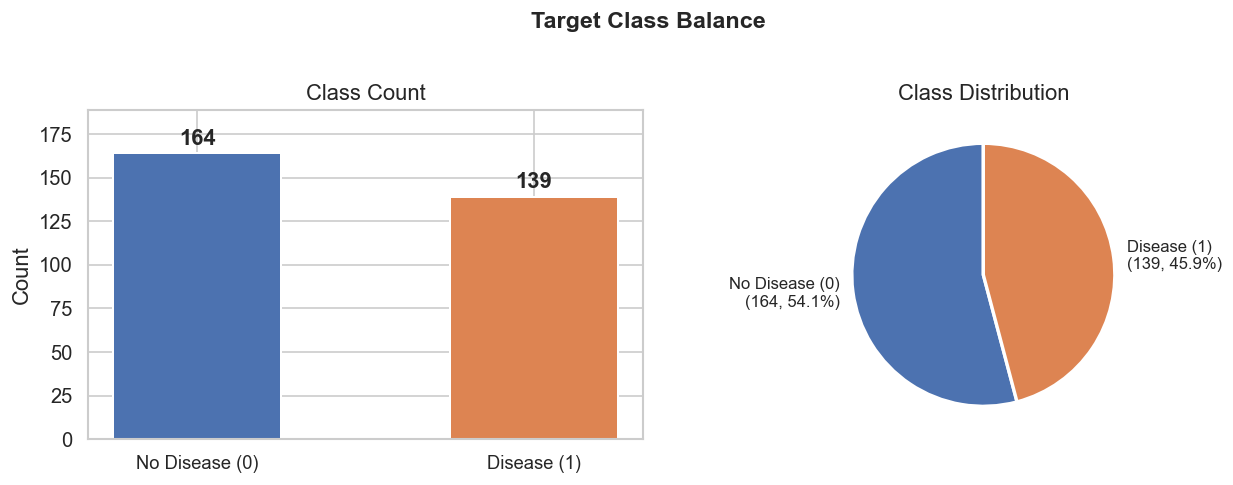


Class ratio (0:1) = 1.18:1
→ Mild imbalance — class_weight='balanced' on LR & RF is sufficient; SMOTE not required.


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

counts = df["target"].value_counts().sort_index()
labels = ["No Disease (0)", "Disease (1)"]
colors = [PALETTE[0], PALETTE[1]]

# Bar chart
axes[0].bar(labels, counts.values, color=colors, edgecolor="white", linewidth=1.2, width=0.5)
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 5, str(v), ha="center", fontweight="bold")
axes[0].set(title="Class Count", ylabel="Count", ylim=(0, counts.max() * 1.15))
axes[0].tick_params(axis="x", labelsize=11)

# Pie chart
axes[1].pie(
    counts.values,
    labels=[f"{l}\n({v}, {v/len(df)*100:.1f}%)" for l, v in zip(labels, counts.values)],
    colors=colors,
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2},
    textprops={"fontsize": 10},
)
axes[1].set_title("Class Distribution")

fig.suptitle("Target Class Balance", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("class_balance.png", bbox_inches="tight")
plt.show()

ratio = counts[0] / counts[1]
print(f"\nClass ratio (0:1) = {ratio:.2f}:1")
print("→ Mild imbalance — class_weight='balanced' on LR & RF is sufficient; SMOTE not required.")


## 4 · Feature Histograms
All 13 features plotted as histograms, split by class (blue = no disease, orange = disease).  
This reveals distributional shifts that signal predictive power.


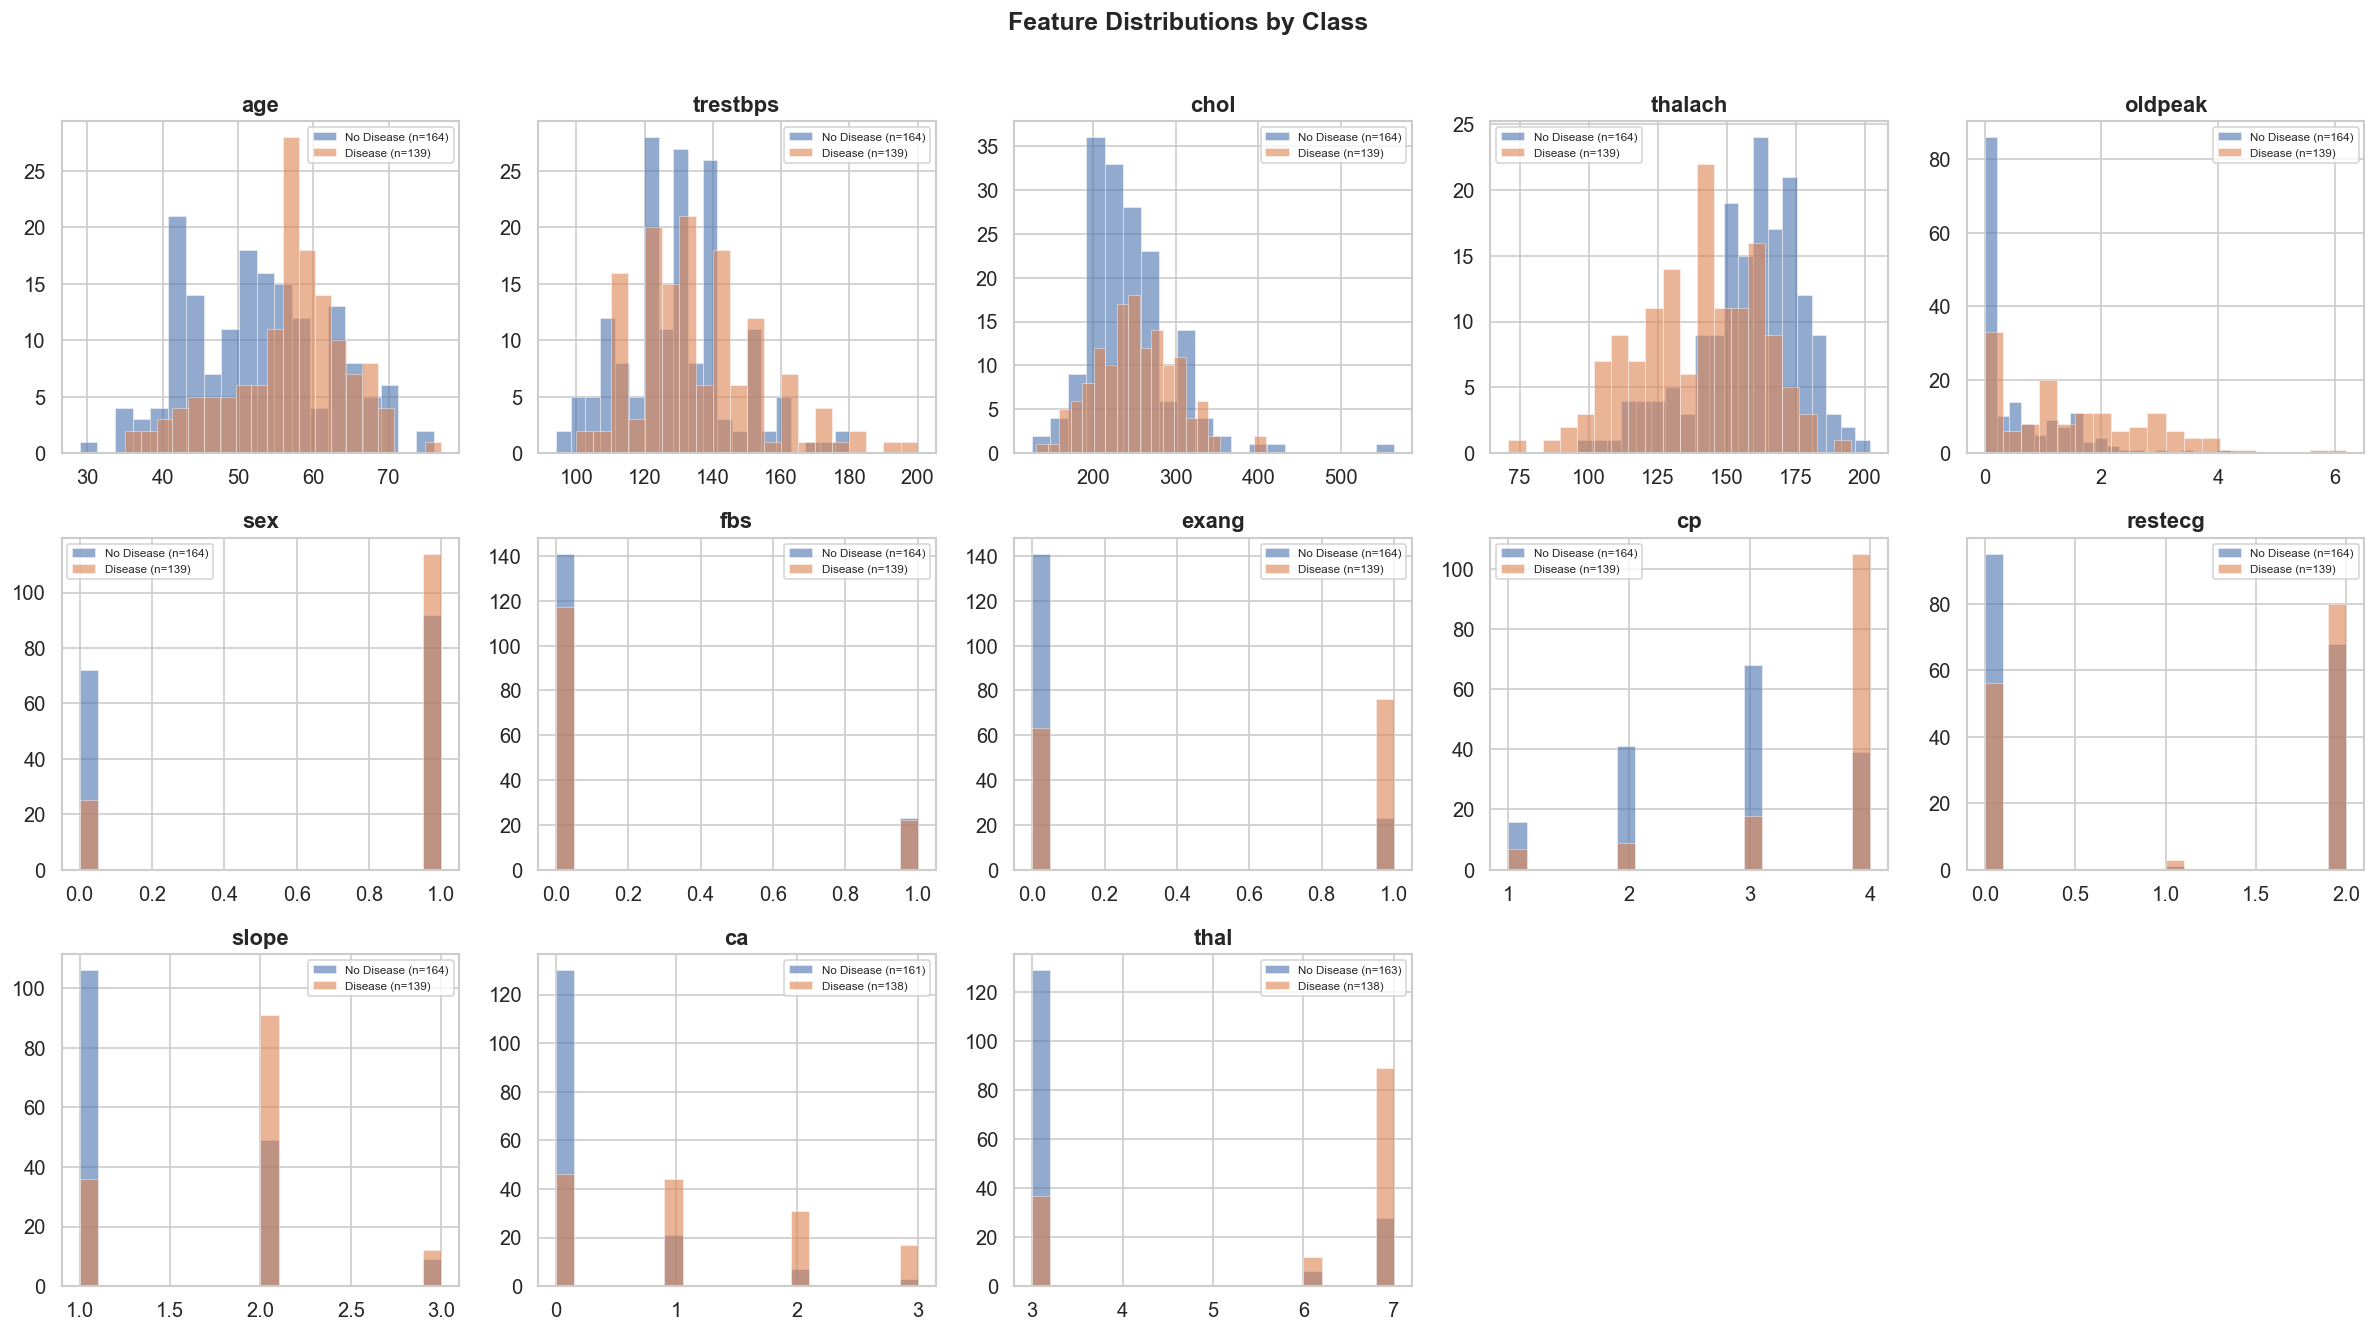

In [15]:
FEATURES = ["age", "trestbps", "chol", "thalach", "oldpeak",
            "sex", "fbs", "exang", "cp", "restecg", "slope", "ca", "thal"]

fig, axes = plt.subplots(3, 5, figsize=(20, 11))
axes = axes.flatten()

for i, feat in enumerate(FEATURES):
    ax = axes[i]
    for cls in [0, 1]:
        subset = df[df["target"] == cls][feat].dropna()
        ax.hist(
            subset,
            bins=20,
            alpha=0.6,
            color=PALETTE[cls],
            label=f"{'No Disease' if cls == 0 else 'Disease'} (n={len(subset)})",
            edgecolor="white",
            linewidth=0.4,
        )
    ax.set_title(feat, fontweight="bold")
    ax.set_xlabel("")
    ax.legend(fontsize=7)

# Hide unused subplot
for j in range(len(FEATURES), len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Feature Distributions by Class", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("feature_histograms.png", bbox_inches="tight")
plt.show()


## 5 · Continuous Features — Box Plots by Class
Box plots surface median shifts and outlier differences between classes  
more cleanly than histograms for continuous variables.


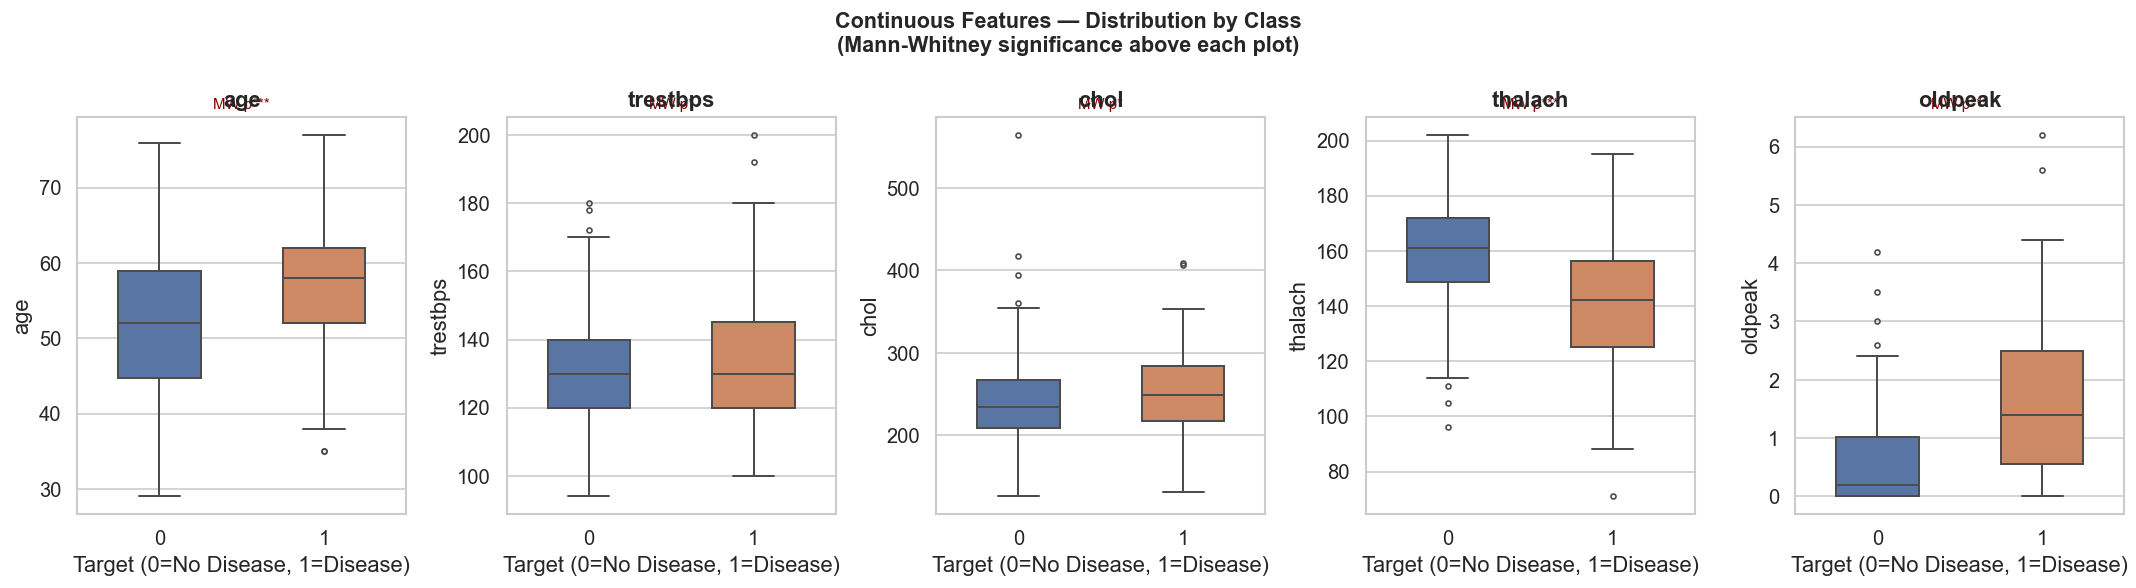

In [17]:
fig, axes = plt.subplots(1, 5, figsize=(18, 5))

for ax, feat in zip(axes, CONTINUOUS):
    sns.boxplot(
        data=df, x="target", y=feat, palette={str(k): v for k, v in PALETTE.items()},
        width=0.5, linewidth=1.2, flierprops={"marker": "o", "markersize": 3}, ax=ax
    )
    ax.set_title(feat, fontweight="bold")
    ax.set_xlabel("Target (0=No Disease, 1=Disease)")
    # Significance annotation (Mann-Whitney)
    from scipy.stats import mannwhitneyu
    g0 = df[df["target"] == 0][feat].dropna()
    g1 = df[df["target"] == 1][feat].dropna()
    stat, p = mannwhitneyu(g0, g1, alternative="two-sided")
    sig = "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else "ns"))
    y_max = df[feat].dropna().max()
    ax.text(0.5, 1.02, f"MW p{sig}", transform=ax.transAxes,
            ha="center", fontsize=9, color="darkred")

fig.suptitle("Continuous Features — Distribution by Class\n(Mann-Whitney significance above each plot)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("boxplots_by_class.png", bbox_inches="tight")
plt.show()


## 6 · Correlation Heatmap
Pearson correlation matrix across all numeric columns including `target`.  
Key questions:
- Which features correlate most strongly with the target?
- Are any feature pairs highly collinear (potential redundancy)?


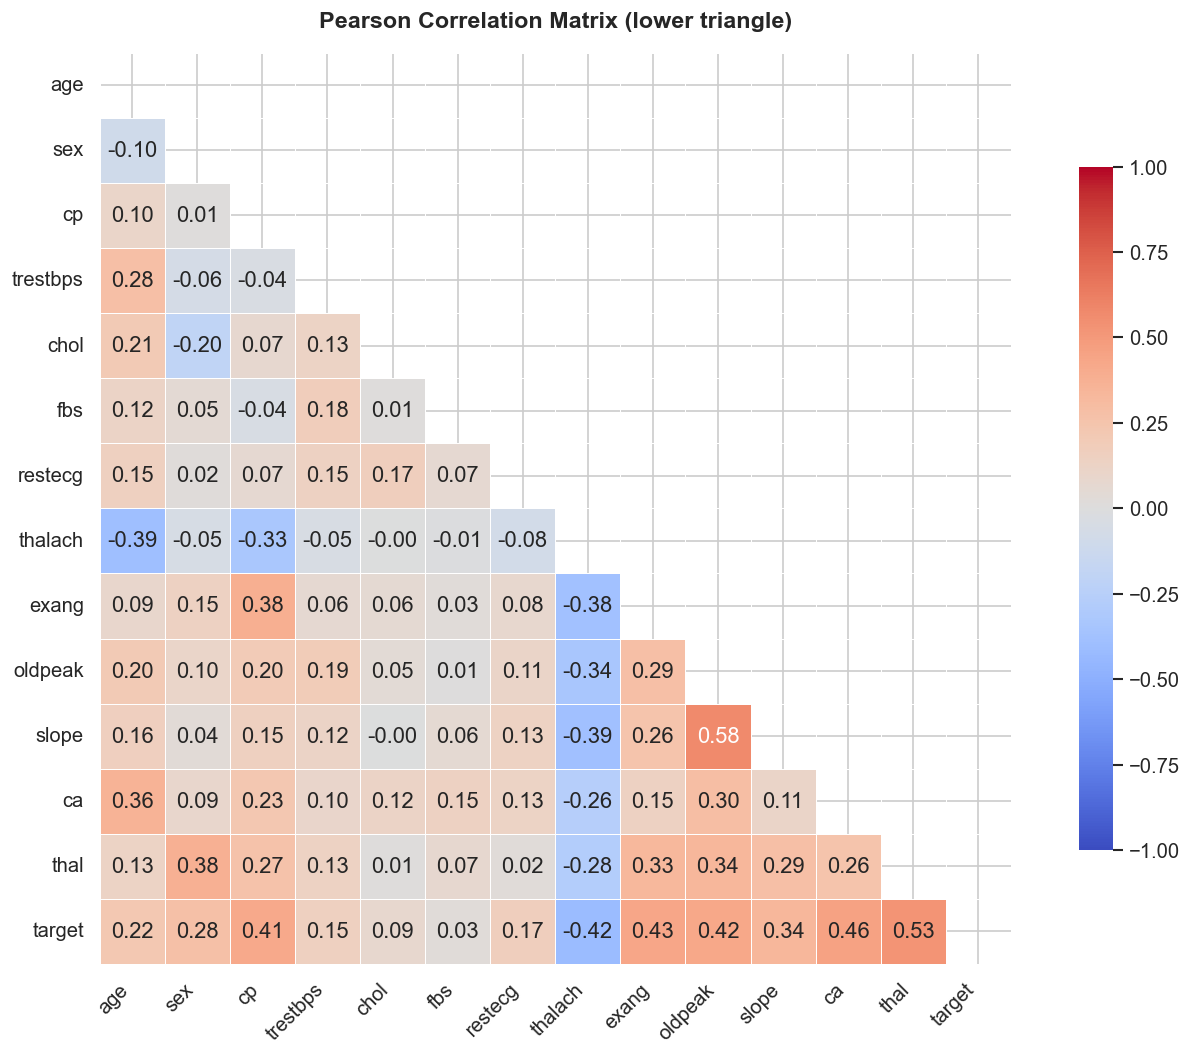


=== Top correlations with target ===
thal        0.525689
ca          0.460442
exang       0.431894
oldpeak     0.424510
thalach     0.417167
cp          0.414446
slope       0.339213
sex         0.276816
age         0.223120
restecg     0.169202
trestbps    0.150825
chol        0.085164
fbs         0.025264


In [18]:
fig, ax = plt.subplots(figsize=(12, 9))

corr = df.copy()
# Encode any string columns if present
for col in corr.select_dtypes(include="object").columns:
    corr[col] = pd.factorize(corr[col])[0]

corr_matrix = corr.corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))   # upper triangle mask

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    linecolor="white",
    square=True,
    cbar_kws={"shrink": 0.75},
    ax=ax,
)

ax.set_title("Pearson Correlation Matrix (lower triangle)", fontsize=14, fontweight="bold", pad=15)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("correlation_heatmap.png", bbox_inches="tight")
plt.show()

# Print top correlations with target
print("\n=== Top correlations with target ===")
target_corr = corr_matrix["target"].drop("target").abs().sort_values(ascending=False)
print(target_corr.to_string())


## 7 · Pairplot — Key Continuous Features
Pairwise scatter plots for the 5 continuous features, coloured by class.  
Reveals linear separability and interaction effects between features.


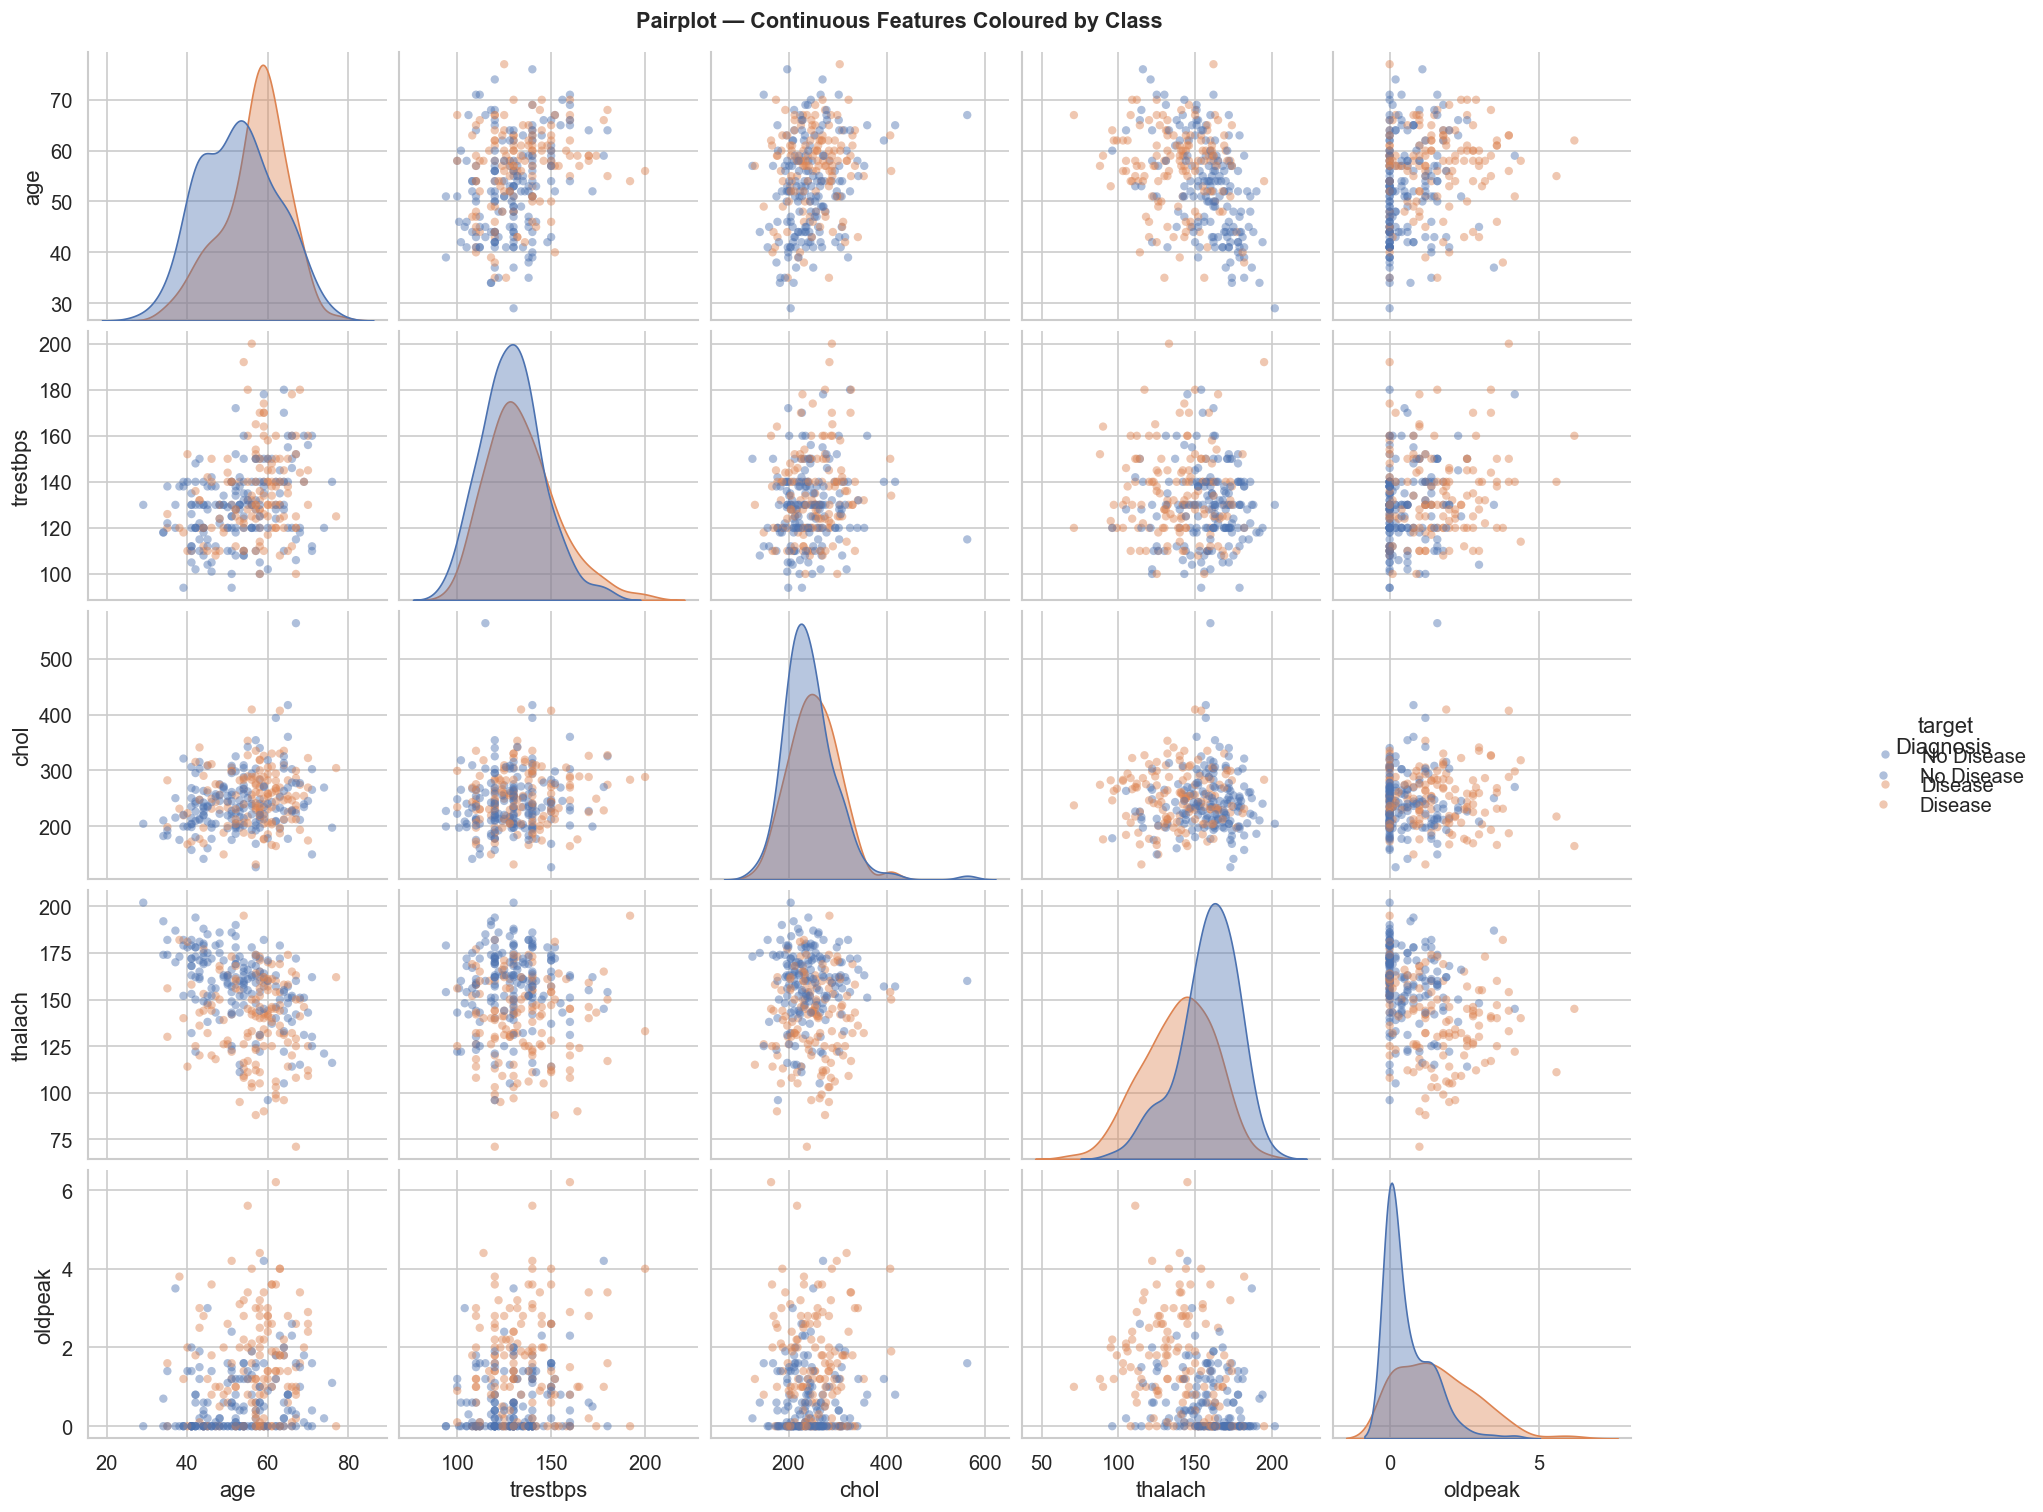

Note: KDE on diagonal shows distributional separation per feature.


In [19]:
pair_df = df[CONTINUOUS + ["target"]].copy()
pair_df["target"] = pair_df["target"].map({0: "No Disease", 1: "Disease"})

g = sns.pairplot(
    pair_df,
    hue="target",
    palette={"No Disease": PALETTE[0], "Disease": PALETTE[1]},
    diag_kind="kde",
    plot_kws={"alpha": 0.45, "s": 25, "edgecolor": "none"},
    diag_kws={"fill": True, "alpha": 0.4},
    corner=False,
)

g.figure.suptitle(
    "Pairplot — Continuous Features Coloured by Class",
    fontsize=13, fontweight="bold", y=1.01
)
g.add_legend(title="Diagnosis", bbox_to_anchor=(1.01, 0.5), loc="center left")

plt.savefig("pairplot_continuous.png", bbox_inches="tight")
plt.show()
print("Note: KDE on diagonal shows distributional separation per feature.")


## 8 · Categorical Feature Breakdown
Count plots for all categorical/binary features split by class.  
Highlights which categories skew toward disease or no-disease.


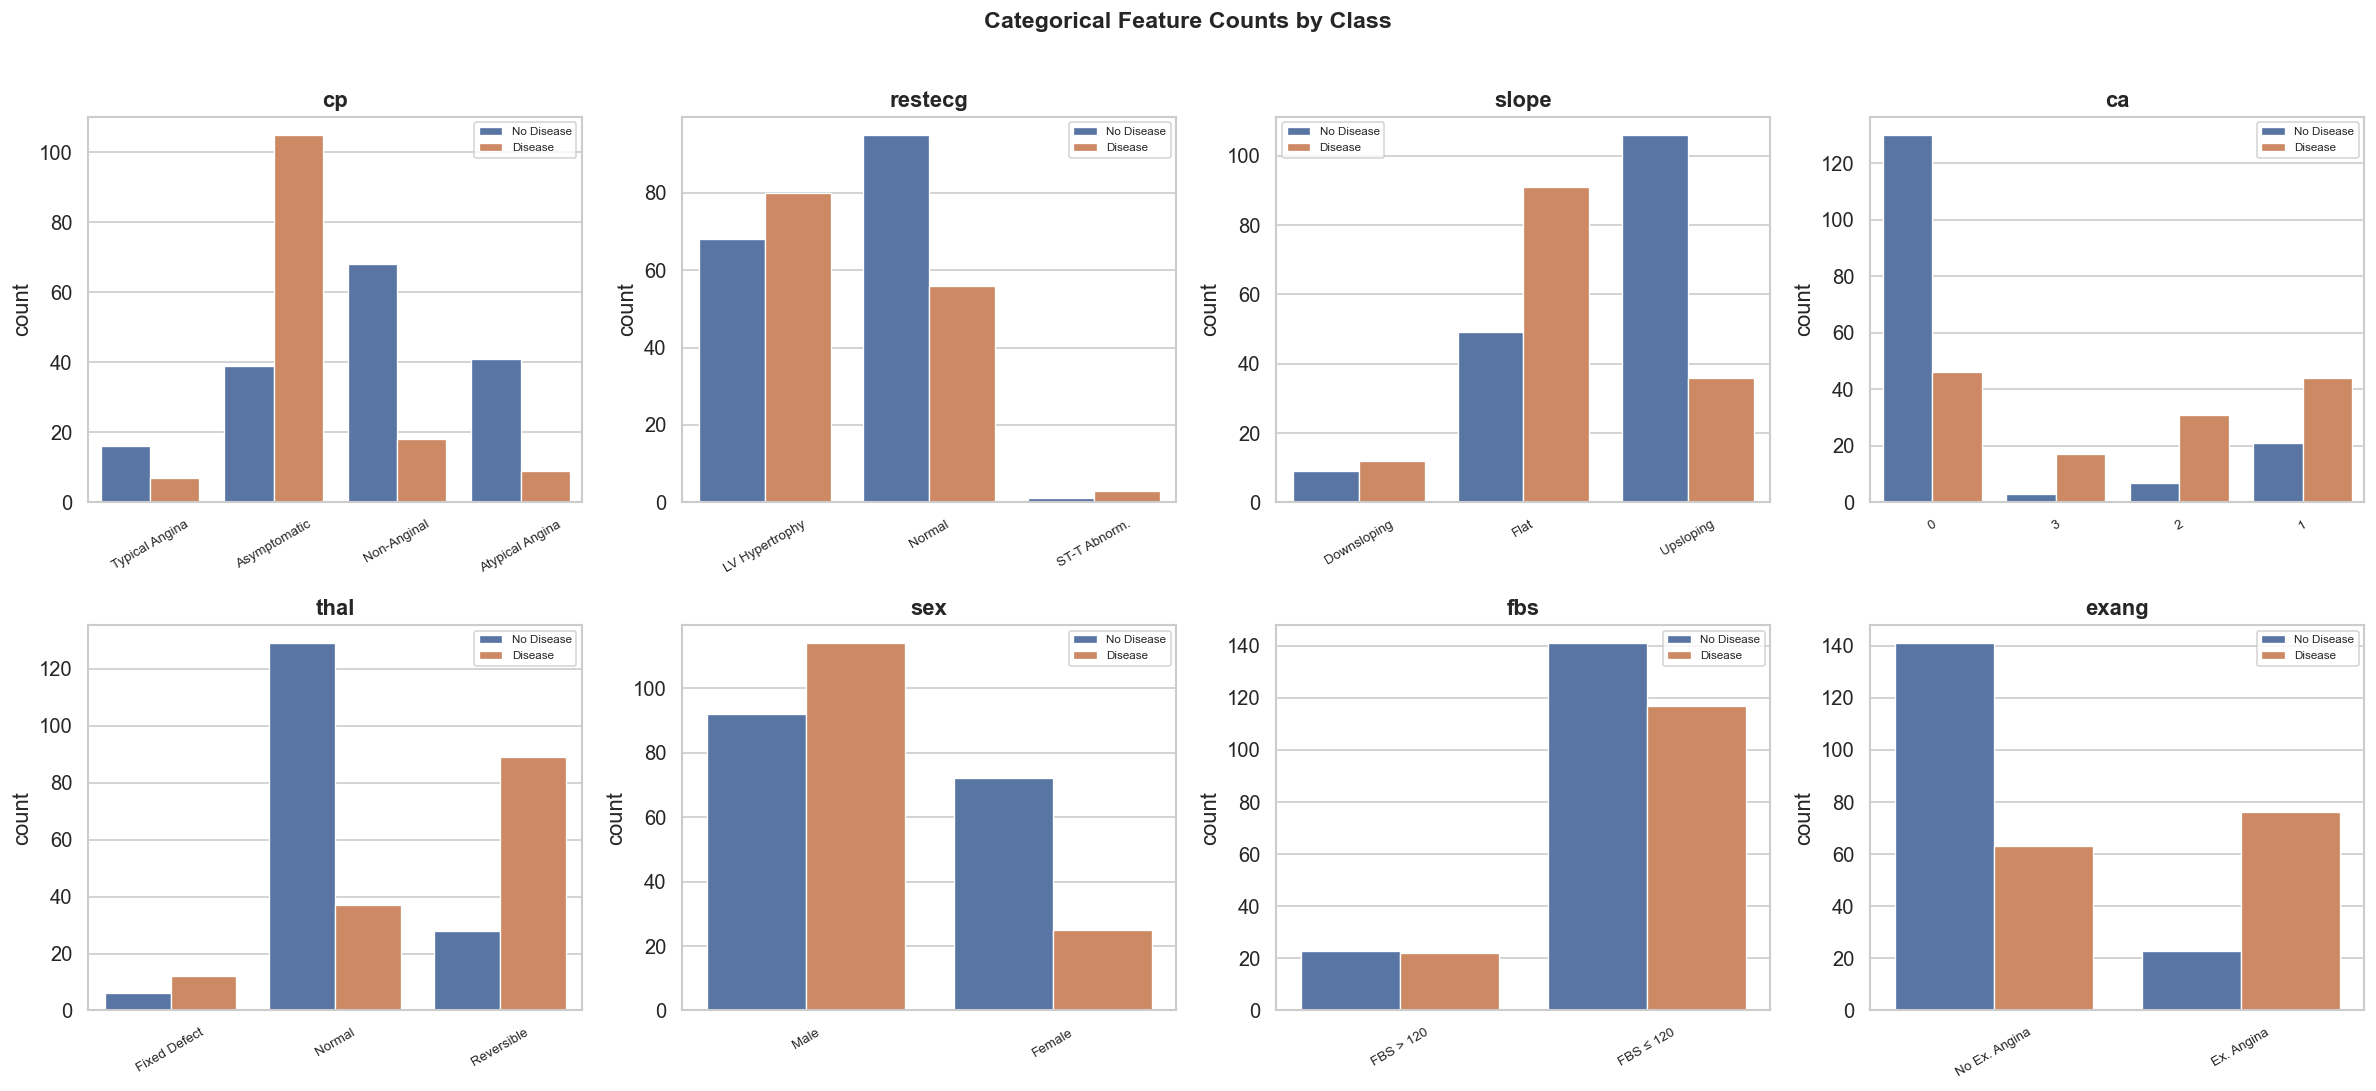

In [20]:
CATEGORICAL = {
    "cp":      {1: "Typical Angina", 2: "Atypical Angina", 3: "Non-Anginal", 4: "Asymptomatic"},
    "restecg": {0: "Normal", 1: "ST-T Abnorm.", 2: "LV Hypertrophy"},
    "slope":   {1: "Upsloping", 2: "Flat", 3: "Downsloping"},
    "ca":      {0: "0", 1: "1", 2: "2", 3: "3"},
    "thal":    {3: "Normal", 6: "Fixed Defect", 7: "Reversible"},
    "sex":     {0: "Female", 1: "Male"},
    "fbs":     {0: "FBS ≤ 120", 1: "FBS > 120"},
    "exang":   {0: "No Ex. Angina", 1: "Ex. Angina"},
}

fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes = axes.flatten()

for ax, (feat, label_map) in zip(axes, CATEGORICAL.items()):
    plot_df = df[[feat, "target"]].copy().dropna()
    plot_df[feat] = plot_df[feat].map(label_map).fillna(plot_df[feat].astype(str))
    plot_df["Diagnosis"] = plot_df["target"].map({0: "No Disease", 1: "Disease"})

    sns.countplot(
        data=plot_df, x=feat, hue="Diagnosis",
        palette={"No Disease": PALETTE[0], "Disease": PALETTE[1]},
        edgecolor="white", linewidth=0.8, ax=ax,
    )
    ax.set_title(feat, fontweight="bold")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=30, labelsize=8)
    ax.legend(fontsize=7, title="")

fig.suptitle("Categorical Feature Counts by Class", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("categorical_breakdown.png", bbox_inches="tight")
plt.show()


## 9 · Key Findings Summary

| # | Finding | Implication for Modelling |
|---|---------|--------------------------|
| 1 | **Class balance ~54:46** — mild skew only | `class_weight='balanced'` sufficient; SMOTE not needed |
| 2 | **`thalach` (max heart rate)** strongest positive correlate with disease | High-importance feature; retain as-is |
| 3 | **`oldpeak` (ST depression)** strongest positive indicator | RobustScaler appropriate — clinical outliers are real |
| 4 | **`cp=4` (Asymptomatic chest pain)** disproportionately linked to disease | Counter-intuitive but well-documented clinically |
| 5 | **`ca` and `thal`** have 1–2% missing values | Most-frequent imputation justified (near-nominal, few gaps) |
| 6 | **`chol` and `trestbps`** show heavy right tails / outliers | Confirms RobustScaler over StandardScaler choice |
| 7 | **`sex=Male`** skewed toward disease in the dataset | Dataset composition bias — not a causal claim |
| 8 | **`age` + `thalach` scatter** shows clear class separation in pairplot | Interaction term could be engineered if needed |

### Feature Importance Forecast
Based on correlation alone, the expected ranking is:  
`thalach` > `cp` > `ca` > `oldpeak` > `thal` > `exang` > `age` > `slope`

This will be confirmed against the trained model's feature importance plots in `train.py`.
